In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, Model
from tensorflow.keras.datasets import mnist

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


In [ ]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize pixel values to 0-1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add channel dimension
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training data: (60000, 28, 28, 1)
Testing data: (10000, 28, 28, 1)


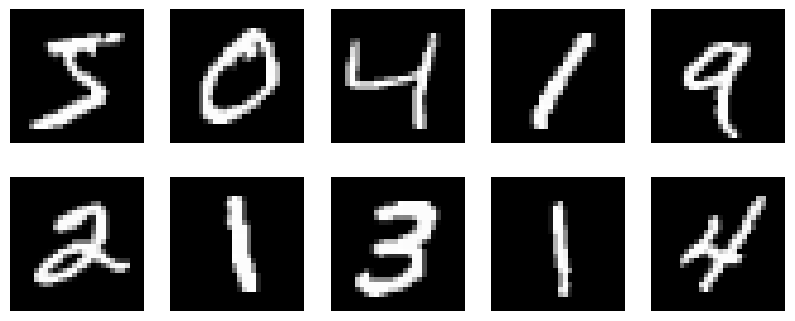

In [ ]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.show()

In [ ]:
latent_dim = 2

In [ ]:
class Sampling(layers.Layer):

    def call(self, inputs):
        z_mean, z_log_var = inputs

        epsilon = tf.random.normal(
            shape=tf.shape(z_mean)
        )

        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [ ]:
encoder_inputs = layers.Input(shape=(28, 28, 1))

x = layers.Flatten()(encoder_inputs)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dense(128, activation="relu")(x)

z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

z = Sampling()([z_mean, z_log_var])

encoder = Model(
    encoder_inputs,
    [z_mean, z_log_var, z],
    name="encoder"
)

encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 784)       │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    200,960 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        258 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        258 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 234,372 (915.52 KB)

 Trainable params: 234,372 (915.52 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
latent_inputs = layers.Input(shape=(latent_dim,))

x = layers.Dense(128, activation="relu")(latent_inputs)
x = layers.Dense(256, activation="relu")(x)

decoder_outputs = layers.Dense(
    28 * 28,
    activation="sigmoid"
)(x)

decoder_outputs = layers.Reshape((28, 28, 1))(decoder_outputs)

decoder = Model(
    latent_inputs,
    decoder_outputs,
    name="decoder"
)

decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 784)            │       201,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 234,896 (917.56 KB)

 Trainable params: 234,896 (917.56 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
class VAE(Model):

    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)

        self.encoder = encoder
        self.decoder = decoder

        self.total_loss_tracker = tf.keras.metrics.Mean(
            name="total_loss"
        )

        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(
            name="reconstruction_loss"
        )

        self.kl_loss_tracker = tf.keras.metrics.Mean(
            name="kl_loss"
        )

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker
        ]

    def train_step(self, data):

        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:

            z_mean, z_log_var, z = self.encoder(data)

            reconstruction = self.decoder(z)

            # Reconstruction loss
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(
                        data,
                        reconstruction
                    ),
                    axis=(1, 2)
                )
            )

            # KL divergence
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var
                    - tf.square(z_mean)
                    - tf.exp(z_log_var),
                    axis=1
                )
            )

            # Total VAE loss
            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(
            total_loss,
            self.trainable_weights
        )

        self.optimizer.apply_gradients(
            zip(grads, self.trainable_weights)
        )

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(
            reconstruction_loss
        )
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss":
                self.reconstruction_loss_tracker.result(),
            "kl_loss":
                self.kl_loss_tracker.result()
        }

In [ ]:
vae = VAE(encoder, decoder)

vae.compile(
    optimizer=tf.keras.optimizers.Adam()
)

In [ ]:
class VAE(Model):

    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)

        self.encoder = encoder
        self.decoder = decoder

        self.total_loss_tracker = tf.keras.metrics.Mean(
            name="loss"
        )

        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(
            name="reconstruction_loss"
        )

        self.kl_loss_tracker = tf.keras.metrics.Mean(
            name="kl_loss"
        )

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker
        ]

    # IMPORTANT: This was missing
    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return reconstruction

    def train_step(self, data):

        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:

            # Encoder
            z_mean, z_log_var, z = self.encoder(data)

            # Decoder
            reconstruction = self.decoder(z)

            # Reconstruction loss
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(
                        data,
                        reconstruction
                    ),
                    axis=(1, 2)
                )
            )

            # KL Divergence
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var
                    - tf.square(z_mean)
                    - tf.exp(z_log_var),
                    axis=1
                )
            )

            # Total loss
            total_loss = reconstruction_loss + kl_loss

        # Calculate gradients
        grads = tape.gradient(
            total_loss,
            self.trainable_weights
        )

        # Update weights
        self.optimizer.apply_gradients(
            zip(grads, self.trainable_weights)
        )

        # Update losses
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(
            reconstruction_loss
        )
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss":
                self.reconstruction_loss_tracker.result(),
            "kl_loss":
                self.kl_loss_tracker.result()
        }

In [ ]:
history = vae.fit(
    x_train,
    epochs=20,
    batch_size=128
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - kl_loss: 4.8683 - loss: 165.9883 - reconstruction_loss: 161.1200
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - kl_loss: 5.2535 - loss: 160.5963 - reconstruction_loss: 155.3428
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - kl_loss: 5.5151 - loss: 156.9505 - reconstruction_loss: 151.4353
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - kl_loss: 5.6736 - loss: 154.6371 - reconstruction_loss: 148.9636
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - kl_loss: 5.8172 - loss: 152.7095 - reconstruction_loss: 146.8924
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - kl_loss: 5.9053 - loss: 151.2031 - reconstruction_loss: 145.2977
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - kl_loss: 6.0101 - loss: 149.8921 - reconstruction_loss: 143.8821
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - kl_loss: 6.0812 - loss: 148.8039 - reconstruction_loss: 142.7227
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━

In [ ]:
def call(self, inputs):
    z_mean, z_log_var, z = self.encoder(inputs)
    reconstruction = self.decoder(z)
    return reconstruction

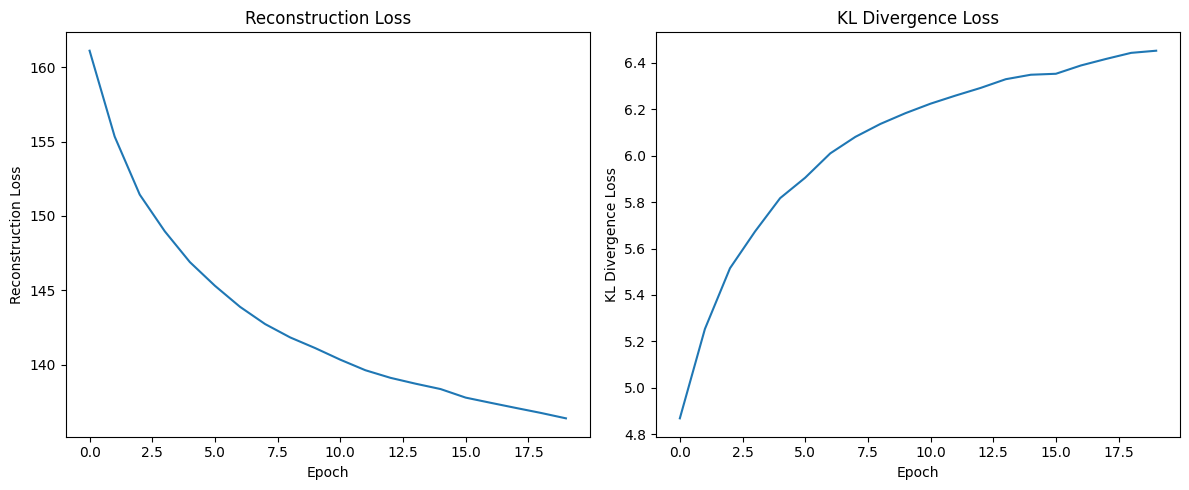

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["reconstruction_loss"])
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.title("Reconstruction Loss")

plt.subplot(1, 2, 2)
plt.plot(history.history["kl_loss"])
plt.xlabel("Epoch")
plt.ylabel("KL Divergence Loss")
plt.title("KL Divergence Loss")

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


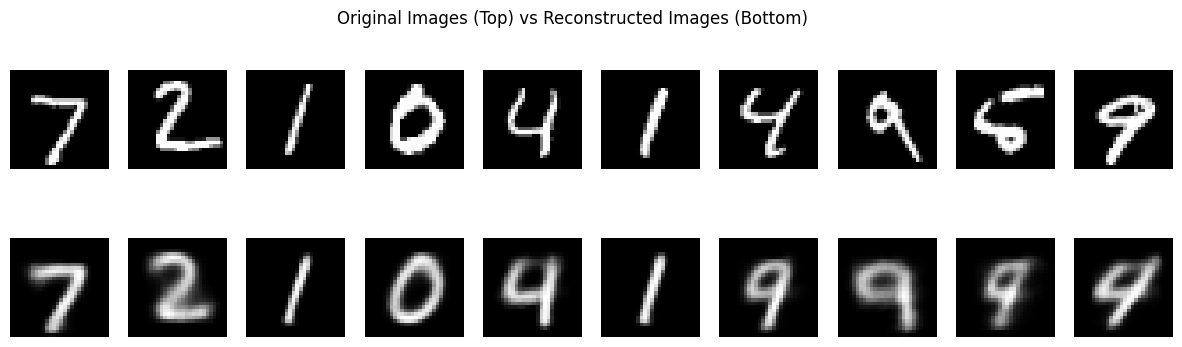

In [ ]:
z_mean, z_log_var, z = encoder.predict(x_test)

reconstructed = decoder.predict(z)

n = 10

plt.figure(figsize=(15, 4))

# Original images
for i in range(n):
    plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.axis("off")

# Reconstructed images
for i in range(n):
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.suptitle("Original Images (Top) vs Reconstructed Images (Bottom)")
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


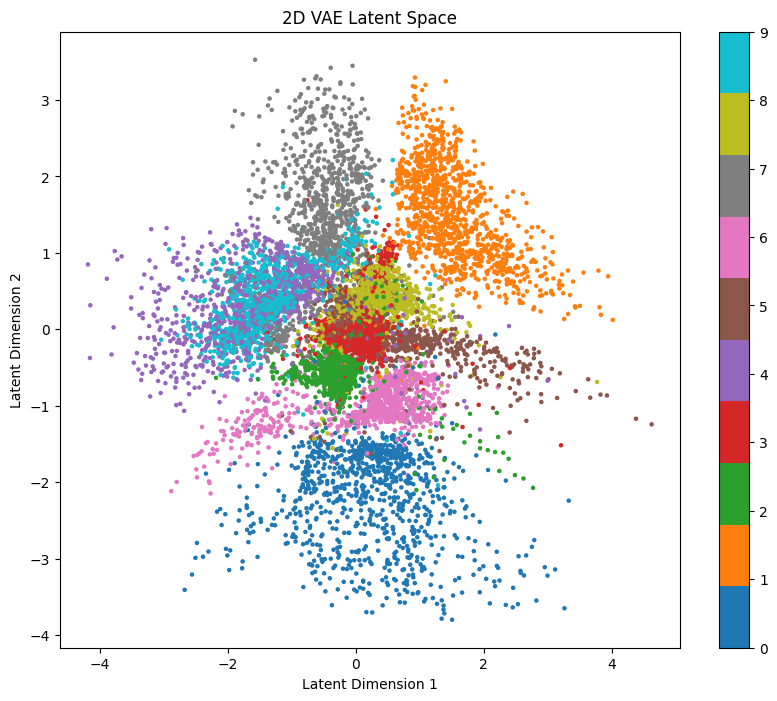

In [ ]:
z_mean, _, _ = encoder.predict(x_test)

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    z_mean[:, 0],
    z_mean[:, 1],
    c=y_test,
    cmap="tab10",
    s=5
)

plt.colorbar(scatter, ticks=range(10))
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.title("2D VAE Latent Space")
plt.show()


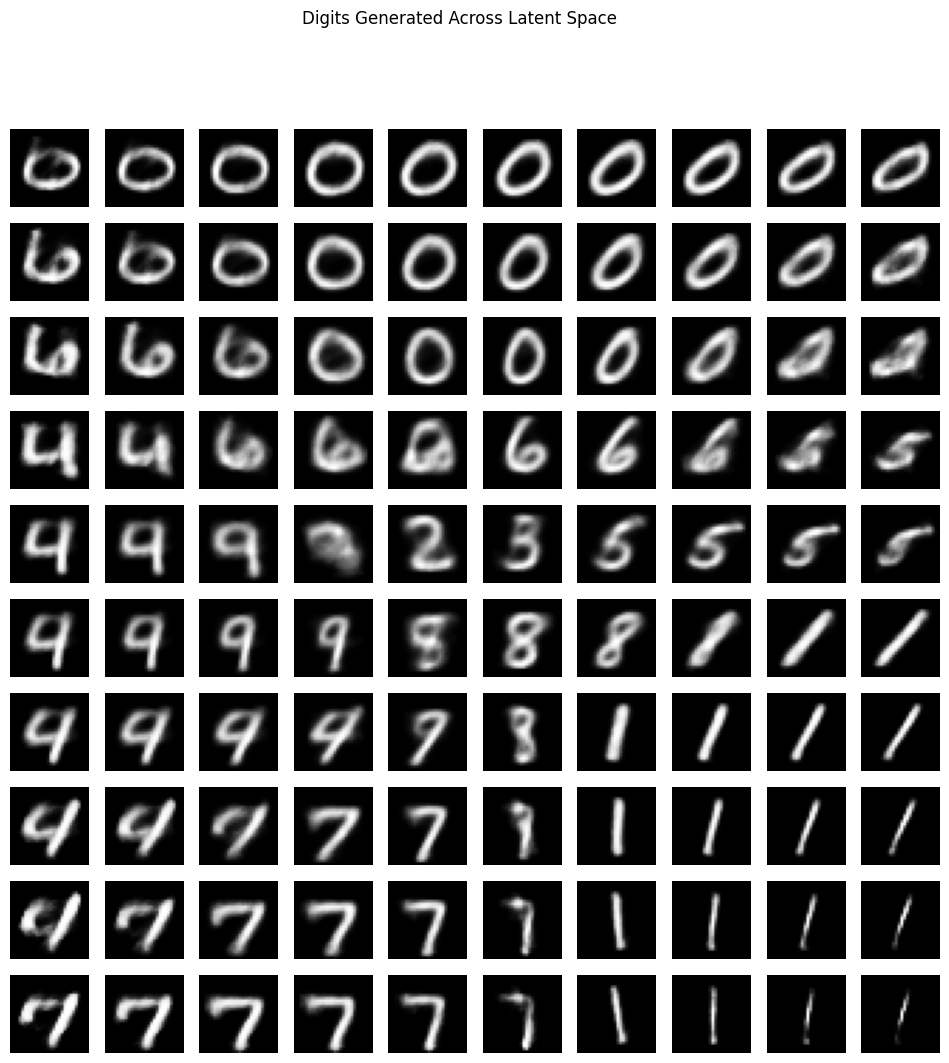

In [ ]:
grid_size = 10

plt.figure(figsize=(12, 12))

grid_x = np.linspace(-3, 3, grid_size)
grid_y = np.linspace(-3, 3, grid_size)

for i, yi in enumerate(grid_y):
    for j, xi in enumerate(grid_x):

        z_sample = np.array([[xi, yi]])

        generated = decoder.predict(
            z_sample,
            verbose=0
        )

        plt.subplot(
            grid_size,
            grid_size,
            i * grid_size + j + 1
        )

        plt.imshow(
            generated[0].squeeze(),
            cmap="gray"
        )

        plt.axis("off")

plt.suptitle("Digits Generated Across Latent Space")
plt.show()

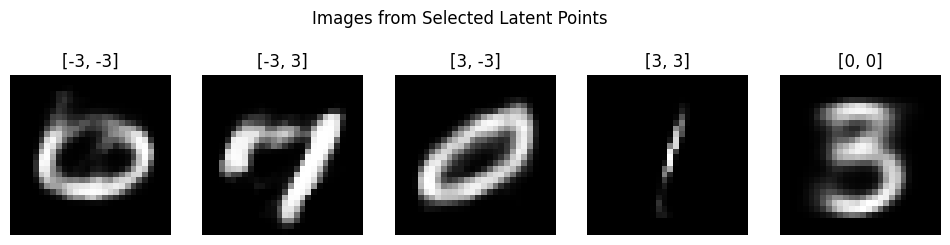

In [ ]:
# Generate images from selected latent points

points = [
    [-3, -3],
    [-3, 3],
    [3, -3],
    [3, 3],
    [0, 0]
]

plt.figure(figsize=(12, 3))

for i, point in enumerate(points):

    z_sample = np.array([point])

    generated = decoder.predict(
        z_sample,
        verbose=0
    )

    plt.subplot(1, 5, i + 1)

    plt.imshow(
        generated[0].squeeze(),
        cmap="gray"
    )

    plt.title(str(point))
    plt.axis("off")

plt.suptitle("Images from Selected Latent Points")
plt.show()


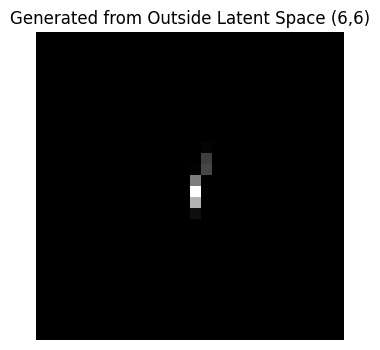

In [ ]:
# Generate image from outside the latent space

outside_point = np.array([[6, 6]])

generated = decoder.predict(
    outside_point,
    verbose=0
)

plt.figure(figsize=(4, 4))

plt.imshow(
    generated[0].squeeze(),
    cmap="gray"
)

plt.title("Generated from Outside Latent Space (6,6)")
plt.axis("off")
plt.show()